<a href="https://colab.research.google.com/github/Harshavardhan2006/23CSBTB27/blob/main/12_09_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Preprocessing**

In [5]:
import re, string
import pandas as pd
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

df = pd.read_csv("tweets.csv")
print(df.head())

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'http\S+|www.\S+', ' ', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [w for w in text.split() if w not in STOPWORDS]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_tweet)
print(df[['text','clean_text']].head())

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_NUM_WORDS = 30000
MAX_SEQ_LEN = 60

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded = pad_sequences(sequences, maxlen=MAX_SEQ_LEN, padding='post')
print("Padded shape:", padded.shape)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   id keyword        location  \
0   0  ablaze             NaN   
1   1  ablaze             NaN   
2   2  ablaze   New York City   
3   3  ablaze  Morgantown, WV   
4   4  ablaze             NaN   

                                                text  target  
0  Communal violence in Bhainsa, Telangana. "Ston...       1  
1  Telangana: Section 144 has been imposed in Bha...       1  
2  Arsonist sets cars ablaze at dealership https:...       1  
3  Arsonist sets cars ablaze at dealership https:...       1  
4  "Lord Jesus, your love brings freedom and pard...       0  
                                                text  \
0  Communal violence in Bhainsa, Telangana. "Ston...   
1  Telangana: Section 144 has been imposed in Bha...   
2  Arsonist sets cars ablaze at dealership https:...   
3  Arsonist sets cars ablaze at dealership https:...   
4  "Lord Jesus, your love brings freedom and pard...   

                                          clean_text  
0  communal violence bhainsa te

**Feature Extraction (CountVectorizer & TF-IDF)**

In [6]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

X_text = df['clean_text']
y = df['target']

cv = CountVectorizer(max_features=20000)
X_cv = cv.fit_transform(X_text)
print("CountVectorizer shape:", X_cv.shape)

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X_text)
print("TF-IDF shape:", X_tfidf.shape)

CountVectorizer shape: (11370, 20000)
TF-IDF shape: (11370, 20000)


##**Deep Learning Models**

**(a) MLP on averaged embeddings**

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(padded, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index)+1)
EMBED_DIM = 100

inp = Input(shape=(MAX_SEQ_LEN,))
x = Embedding(vocab_size, EMBED_DIM, input_length=MAX_SEQ_LEN)(inp)
x = GlobalAveragePooling1D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(1, activation='sigmoid')(x)

mlp_model = Model(inp, out)
mlp_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
mlp_model.summary()

history_mlp = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5, batch_size=64, verbose=2
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 60, 100)        │     2,478,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,491,657 (9.50 MB)

 Trainable params: 2,491,657 (9.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
114/114 - 5s - 43ms/step - accuracy: 0.8070 - loss: 0.4917 - val_accuracy: 0.8038 - val_loss: 0.4897
Epoch 2/5
114/114 - 4s - 37ms/step - accuracy: 0.8129 - loss: 0.4768 - val_accuracy: 0.8038 - val_loss: 0.4859
Epoch 3/5
114/114 - 3s - 24ms/step - accuracy: 0.8129 - loss: 0.4585 - val_accuracy: 0.8038 - val_loss: 0.4604
Epoch 4/5
114/114 - 6s - 48ms/step - accuracy: 0.8292 - loss: 0.3847 - val_accuracy: 0.8467 - val_loss: 0.3490
Epoch 5/5
114/114 - 3s - 28ms/step - accuracy: 0.9035 - loss: 0.2447 - val_accuracy: 0.8703 - val_loss: 0.3421


**(b) 1D CNN**

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D

cnn_model = Sequential([
    Embedding(vocab_size, EMBED_DIM, input_length=MAX_SEQ_LEN),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn_model.summary()

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5, batch_size=64, verbose=2
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
114/114 - 11s - 94ms/step - accuracy: 0.8120 - loss: 0.4721 - val_accuracy: 0.8038 - val_loss: 0.3958
Epoch 2/5
114/114 - 10s - 90ms/step - accuracy: 0.8980 - loss: 0.2542 - val_accuracy: 0.8819 - val_loss: 0.3143
Epoch 3/5
114/114 - 11s - 98ms/step - accuracy: 0.9728 - loss: 0.0826 - val_accuracy: 0.8582 - val_loss: 0.3981
Epoch 4/5
114/114 - 7s - 59ms/step - accuracy: 0.9938 - loss: 0.0226 - val_accuracy: 0.8775 - val_loss: 0.5264
Epoch 5/5
114/114 - 8s - 72ms/step - accuracy: 0.9984 - loss: 0.0080 - val_accuracy: 0.8599 - val_loss: 0.6374


**(c) LSTM Network**

In [24]:
from tensorflow.keras.layers import LSTM, Bidirectional

inp = Input(shape=(MAX_SEQ_LEN,))
x = Embedding(vocab_size, EMBED_DIM, input_length=MAX_SEQ_LEN)(inp)
x = Bidirectional(LSTM(64))(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)

lstm_model = Model(inp, out)
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5, batch_size=64, verbose=2
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 60, 100)        │     2,478,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,571,401 (9.81 MB)

 Trainable params: 2,571,401 (9.81 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
114/114 - 25s - 218ms/step - accuracy: 0.8209 - loss: 0.4569 - val_accuracy: 0.8819 - val_loss: 0.3076
Epoch 2/5
114/114 - 21s - 185ms/step - accuracy: 0.9256 - loss: 0.2016 - val_accuracy: 0.8907 - val_loss: 0.2909
Epoch 3/5
114/114 - 44s - 383ms/step - accuracy: 0.9766 - loss: 0.0766 - val_accuracy: 0.8835 - val_loss: 0.3554
Epoch 4/5
114/114 - 38s - 330ms/step - accuracy: 0.9919 - loss: 0.0281 - val_accuracy: 0.8775 - val_loss: 0.4835
Epoch 5/5
114/114 - 39s - 343ms/step - accuracy: 0.9966 - loss: 0.0138 - val_accuracy: 0.8769 - val_loss: 0.5294


**Evaluation**

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MLP -> Accuracy=0.8734
Precision=0.6149
Recall=0.7298
F1=0.6674


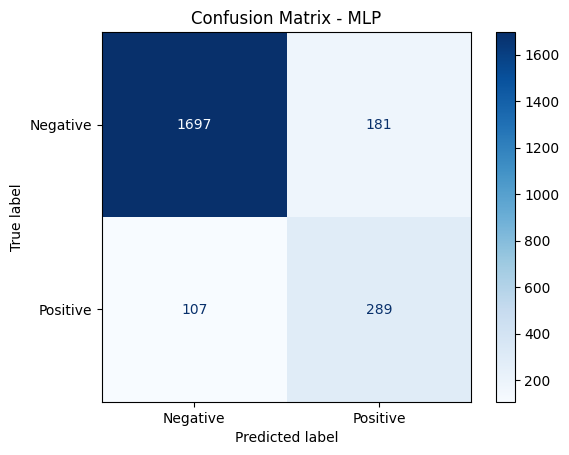

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
CNN -> Accuracy=0.8558
Precision=0.5697
Recall=0.7020
F1=0.6290


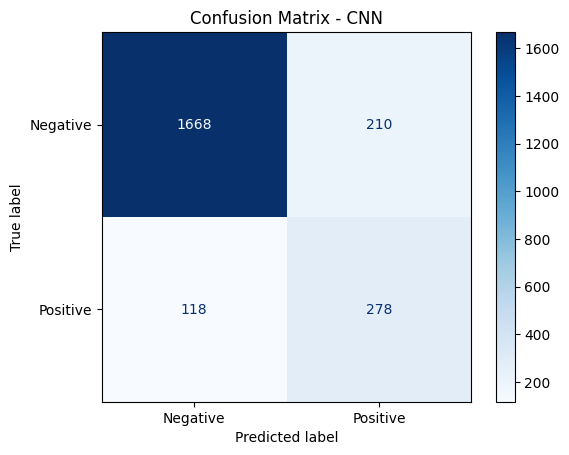

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
LSTM -> Accuracy=0.8804
Precision=0.6462
Recall=0.6919
F1=0.6683


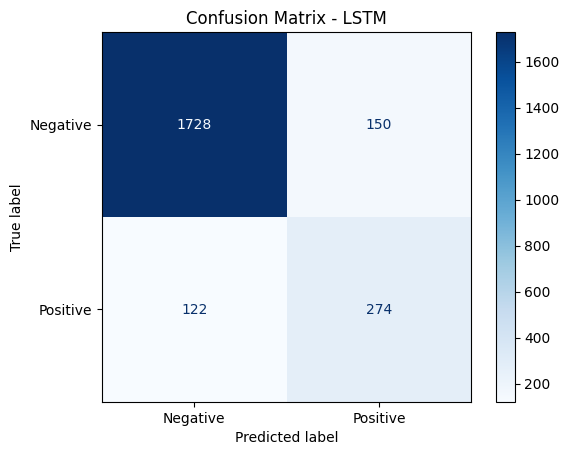

['LSTM',
 0.8803869832893579,
 0.6462264150943396,
 0.6919191919191919,
 0.6682926829268293]

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model_with_cm(model, X_test, y_test, name):
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    print(f"{name} -> Accuracy={acc:.4f}\nPrecision={p:.4f}\nRecall={r:.4f}\nF1={f:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return [name, acc, p, r, f]

evaluate_model_with_cm(mlp_model, X_test, y_test, "MLP")
evaluate_model_with_cm(cnn_model, X_test, y_test, "CNN")
evaluate_model_with_cm(lstm_model, X_test, y_test, "LSTM")

**Compare with Logistic Regression & SVM (TF-IDF features)**

In [38]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_model(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return [name, acc, p, r, f]

results = []

y_pred_lr = lr.predict(X_test_tfidf)
results.append(evaluate_model(y_test, y_pred_lr, "Logistic Regression (TF-IDF)"))

y_pred_svm = svm.predict(X_test_tfidf)
results.append(evaluate_model(y_test, y_pred_svm, "SVM (TF-IDF)"))

y_pred_mlp = (mlp_model.predict(X_test) > 0.5).astype(int)
results.append(evaluate_model(y_test, y_pred_mlp, "MLP (Embeddings)"))

y_pred_cnn = (cnn_model.predict(X_test) > 0.5).astype(int)
results.append(evaluate_model(y_test, y_pred_cnn, "CNN (Embeddings)"))

y_pred_lstm = (lstm_model.predict(X_test) > 0.5).astype(int)
results.append(evaluate_model(y_test, y_pred_lstm, "LSTM (Embeddings)"))

comparison_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
print(comparison_df)


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
                          Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression (TF-IDF)  0.871152   0.905512  0.290404  0.439771
1                  SVM (TF-IDF)  0.987247   0.986737  0.939394  0.962484
2              MLP (Embeddings)  0.873351   0.614894  0.729798  0.667436
3              CNN (Embeddings)  0.855761   0.569672  0.702020  0.628959
4             LSTM (Embeddings)  0.880387   0.646226  0.691919  0.668293
